In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import seaborn as sns

from nilearn import plotting
from nilearn.image import new_img_like

In [2]:
import rsatoolbox
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed, Model
from rsatoolbox.rdm import RDMs
from rsatoolbox.vis import show_rdm, show_rdm_panel

from scipy.spatial.distance import squareform

from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from glob import glob

In [3]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [4]:
project_dir = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 'FLT/')
fmriprep_dir = os.path.join(project_dir, 'derivatives', '22.1.1') # 'fmriprep_noSDC')

bidsroot = os.path.join(project_dir, 'data_denoised')
deriv_dir = os.path.join(bidsroot, 'derivatives')

fwhm_sub = 0
model_dir = os.path.join(deriv_dir, 'glmsingle')

task_list = ['tonecat']
space_label = 'MNI152NLin2009cAsym'

In [5]:
model_dir

'/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle'

## Make models

### FFR RDMs


In [ ]:
'''
# start with grand average FFR
print('loading FFR dissimilarity matrix')
ffr_rdm_fpath = os.path.join(stim_rdm_dir, 'FFRdistancesgrandavg.csv')
rdm_name = 'FFR_grandavg'
ffr_rdm_data = np.genfromtxt(fpath, delimiter=',', skip_header=1)
print(len(ffr_rdm_data))

# input array needs to be 3-dimensional, despite docs saying 2-D is ok
# (thus the newaxis)
ffr_rdm = RDMs(ffr_rdm_data[np.newaxis,:,:],
               rdm_descriptors={'FFR model': rdm_name},
               pattern_descriptors=pattern_descriptors,
               dissimilarity_measure='Euclidean')
ffr_model = ModelFixed('FFR model', ffr_rdm)

ffr_models = [ffr_model]
'''

### Categorical RDMs

In [6]:
tones   = ['T1', 'T2', 'T3', 'T4']
talkers = ['M1', 'M2', 'F1', 'F2']
#reps    = [1, 2, 3]

trials = []

for t in tones:
    for k in talkers:
        #for r in reps:
            trials.append({
                'tone': t,
                'talker': k,
                #'rep': r,
                'stimulus': f'{t}_{k}',
                #'trial_id': f'{t}_{k}_rep-{r}'
            })

len(trials)  # 4 tones x 4 talkers x 3 reps = 48


16

In [7]:
import numpy as np

def build_binary_rdm(labels):
    n = len(labels)
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            rdm[i, j] = 0 if labels[i] == labels[j] else 1
    return rdm


In [8]:
tone_labels   = [t['tone'] for t in trials]
talker_labels = [t['talker'] for t in trials]
#rep_labels    = [t['rep'] for t in trials]

tone_model   = build_binary_rdm(tone_labels)
talker_model = build_binary_rdm(talker_labels)
#rep_model    = build_binary_rdm(rep_labels)


In [9]:
tone_model

array([[0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,

In [10]:
obs_desc = {
    'tone': tone_labels,
    'talker': talker_labels,
    #'rep': rep_labels,
    'stimulus': [t['stimulus'] for t in trials],
    #'trial_id': [t['trial_id'] for t in trials]
}

tone_rdm = rsatoolbox.rdm.RDMs(
    dissimilarities=tone_model[None, :, :],
    dissimilarity_measure='binary',
    pattern_descriptors=obs_desc
)

talker_rdm = rsatoolbox.rdm.RDMs(
    dissimilarities=talker_model[None, :, :],
    dissimilarity_measure='binary',
    pattern_descriptors=obs_desc
)
'''
rep_rdm = rsatoolbox.rdm.RDMs(
    dissimilarities=rep_model[None, :, :],
    dissimilarity_measure='binary',
    pattern_descriptors=obs_desc
)
'''

"\nrep_rdm = rsatoolbox.rdm.RDMs(\n    dissimilarities=rep_model[None, :, :],\n    dissimilarity_measure='binary',\n    pattern_descriptors=obs_desc\n)\n"

In [11]:
assert tone_rdm.n_rdm == 1
assert tone_rdm.n_cond == 16 # 48 if rep included
assert len(tone_rdm.pattern_descriptors['tone']) == 16 # 48 if rep included


"\nfig, ax, ret_val = show_rdm(rep_rdm, \n                            rdm_descriptor='repetition', \n                            pattern_descriptor='rep', \n                            cmap='gray_r', figsize=(5,5))\nfig.show()\n"

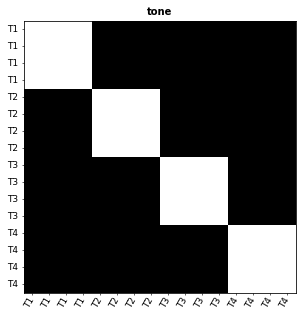

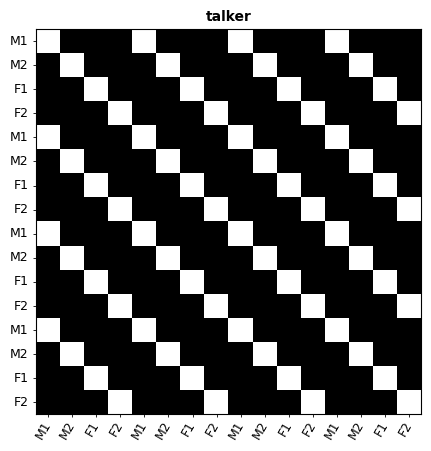

In [12]:
fig, ax, ret_val = show_rdm(tone_rdm, 
                            rdm_descriptor='tone', 
                            pattern_descriptor='tone', 
                            cmap='gray_r', figsize=(5,5))
fig.show()

fig, ax, ret_val = show_rdm(talker_rdm, 
                            rdm_descriptor='talker', 
                            pattern_descriptor='talker', 
                            cmap='gray_r', figsize=(5,5))
fig.show()

'''
fig, ax, ret_val = show_rdm(rep_rdm, 
                            rdm_descriptor='repetition', 
                            pattern_descriptor='rep', 
                            cmap='gray_r', figsize=(5,5))
fig.show()
'''

In [13]:
cat_rdms = [tone_rdm, talker_rdm] #, rep_rdm]
print(len(cat_rdms))

2


#### Convert from RDM to Model

In [14]:
tone_model = ModelFixed( 'Tone Model', tone_rdm)
talker_model = ModelFixed( 'Talker Model', talker_rdm)
#rep_model = ModelFixed( 'Repetition Model', rep_rdm)
cat_models = [tone_model, talker_model] #, rep_model]

In [15]:
cat_models

In [16]:
tone_model.name

'Tone Model'

## Set up participants

In [17]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = [ 'sub-FLT06', 'sub-FLT08',
                'sub-FLT07',
                'sub-FLT27', 
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index,
                     inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], 
                            ignore_index=True, 
                            inplace=True)

In [18]:
participants_df

,participant_id,age,sex,group,FFR_id
0,sub-FLT02,21,F,non-Mandarin,1002.0
1,sub-FLT03,25,F,Mandarin,2002.0
2,sub-FLT04,21,F,non-Mandarin,1003.0
3,sub-FLT05,26,M,Mandarin,3010.0
4,sub-FLT09,30,F,non-Mandarin,3002.0
5,sub-FLT10,23,F,Mandarin,2006.0
6,sub-FLT11,20,F,non-Mandarin,1005.0
7,sub-FLT12,20,F,non-Mandarin,3004.0
8,sub-FLT13,23,F,non-Mandarin,3005.0
9,sub-FLT14,23,M,non-Mandarin,3006.0


In [19]:
# create group-specific lists of subject IDs
sub_group_dict = {'Mandarin': list(participants_df.participant_id[participants_df.group=='Mandarin']),
                  'non-Mandarin': list(participants_df.participant_id[participants_df.group=='non-Mandarin'])}

In [20]:
len(sub_group_dict['Mandarin'])

12

In [21]:
sub_group_dict

{'Mandarin': ['sub-FLT03',
  'sub-FLT05',
  'sub-FLT10',
  'sub-FLT15',
  'sub-FLT17',
  'sub-FLT18',
  'sub-FLT19',
  'sub-FLT21',
  'sub-FLT22',
  'sub-FLT23',
  'sub-FLT24',
  'sub-FLT26'],
 'non-Mandarin': ['sub-FLT02',
  'sub-FLT04',
  'sub-FLT09',
  'sub-FLT11',
  'sub-FLT12',
  'sub-FLT13',
  'sub-FLT14',
  'sub-FLT20',
  'sub-FLT25',
  'sub-FLT28',
  'sub-FLT30']}

In [22]:
mask_list = [
             'L-IC', 'L-MGN', 'L-HG', 'L-PP', 'L-PT', 
             'L-STGp', #'L-STGa', 'L-ParsOp', 'L-ParsTri',
             'R-IC', 'R-MGN', 'R-HG', 'R-PP', 'R-PT', 
             'R-STGp', #'R-STGa', 'R-ParsOp', 'R-ParsTri',
             ]

In [23]:
participant_list = participants_df.participant_id
participant_list = [p.split('-')[1] for p in participant_list]
group_assignment = participants_df.group

## Across-run (`crossnobis`)

In [24]:
model_dir

'/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle'

### Load subject-specific RDMs

In [64]:
# from `rsa_roi.py`-generated outputs
calc_method = 'crossnobis'

group_rdm_list = []
for sx, sub_id in enumerate(participant_list):
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, f'rsa-roi_glmsingle_rdmcalc-{calc_method}')
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_glmsingle_trial_auditory_{calc_method}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # subject-level descriptors
    sub_rdm.descriptors['participant'] = sub_id
    sub_rdm.descriptors['group'] = group_id
    group_rdm_list.append(sub_rdm)
    
ref = group_rdm_list[0].pattern_descriptors['stimulus']
for rdm in group_rdm_list[1:]:
    assert rdm.pattern_descriptors['stimulus'] == ref

group_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list)

FLT02
FLT03
FLT04
FLT05
FLT09
FLT10
FLT11
FLT12
FLT13
FLT14
FLT15
FLT17
FLT18
FLT19
FLT20
FLT21
FLT22
FLT23
FLT24
FLT25
FLT26
FLT28
FLT30


In [65]:
group_rdms.n_cond

16

In [66]:
group_rdms.n_rdm

358

In [67]:
group_rdms.pattern_descriptors.keys()


dict_keys(['index', 'stimulus'])

In [68]:
group_rdms.rdm_descriptors.keys()

dict_keys(['group', 'noise', 'ROI', 'participant', 'index'])

In [51]:
square_dir = os.path.join(out_dir, 'rdm_csv')
os.makedirs(square_dir, exist_ok=True)

for rdm_i in range(group_rdms.n_rdm):

    rdm = group_rdms[rdm_i]

    sub = rdm.rdm_descriptors['participant'][0]
    roi = rdm.rdm_descriptors['ROI'][0]
    run = rdm.rdm_descriptors['run'][0]
    
    mat = squareform(rdm.dissimilarities[0])
    labels = rdm.pattern_descriptors['index']  # or 'condition'

    df = pd.DataFrame(mat, index=labels, columns=labels)

    fname = f'sub-{sub}_roi-{roi}_rdm.csv'
    #df.to_csv(os.path.join(square_dir, fname))
    

In [52]:
print(square_dir)

/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/rsa-roi_glmsingle_rdmcalc-correlation/rdm_csv


#### Group-average RDMs

In [69]:
roi_names = np.unique(group_rdms.rdm_descriptors['ROI'])

mean_roi_rdms = []

for roi in roi_names:
    roi_rdms = group_rdms.subset('ROI', roi)

    # ---- average across participants ----
    mean_rdm = roi_rdms.mean()

    # keep ROI info
    mean_rdm.rdm_descriptors['ROI'] = [roi]

    mean_roi_rdms.append(mean_rdm)

mean_roi_rdms = rsatoolbox.rdm.rdms.concat(mean_roi_rdms)


In [70]:
mean_roi_rdms

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
crossnobis
dissimilarities = 
[[ 0.07503715  0.01971839  0.05668079 ... -0.06029659 -0.19290091
   0.02258083]
 [ 0.09463461  0.43346103  0.09320352 ... -0.00790515 -0.22668
   0.01738816]
 [-0.18779741  0.19780751  0.28298618 ...  0.11265519 -0.10808208
  -0.38490233]
 ...
 [ 0.24407594  0.15230506 -0.03971959 ... -0.20046779  0.55823129
   0.12695169]
 [ 0.3063311   0.6419344  -0.21832486 ... -0.10297061  0.28884399
  -0.05042135]
 [-0.23711384  0.72435839  1.24213798 ...  0.50447379 -0.62503111
  -0.22011551]]
descriptors = 
{'cv_descriptor': 'run'}
rdm_descriptors = 
{'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'ROI': ['L-HG', 'L-IC', 'L-MGN', 'L-PP', 'L-PT', 'L-ParsOp', 'L-ParsTri', 'L-STGa', 'L-STGp', 'R-HG', 'R-IC', 'R-MGN', 'R-PP', 'R-PT', 'R-ParsOp', 'R-ParsTri', 'R-STGa', 'R-STGp']}
pattern_descriptors = 
{'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'stimulus': ['di1_aN', 'di1_bN',

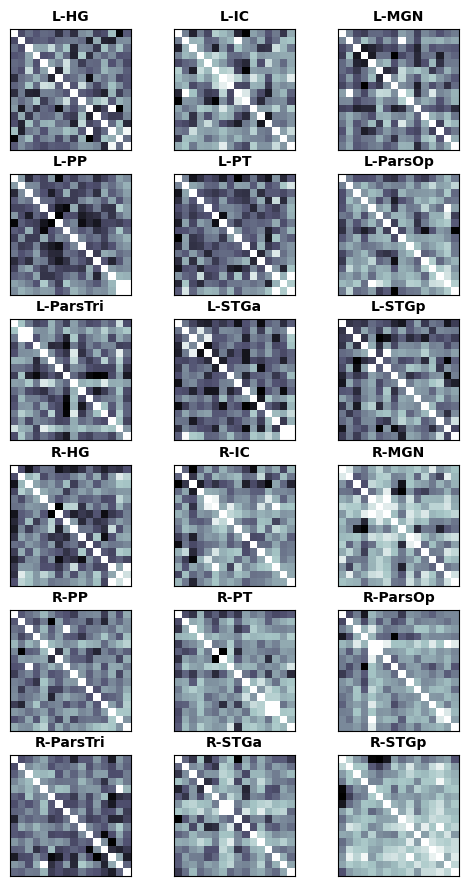

In [71]:
rsatoolbox.vis.show_rdm(mean_roi_rdms, 
                        rdm_descriptor='ROI', 
                        show_colorbar=None,#'panel', 
                        #pattern_descriptor='stimulus',
                        n_column=3,
                       )
plt.show()

In [72]:
rdm_df = group_rdms.to_df()

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:43: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = getattr(asarray(obj), method)(*args, **kwds)


In [73]:
rdm_df

,dissimilarity,group,noise,ROI,participant,rdm_index,pattern_index_1,pattern_index_2,stimulus_1,stimulus_2
0,-0.160114,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",L-IC,FLT02,0,0,1,di1_aN,di1_bN
1,1.257618,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",L-IC,FLT02,0,0,2,di1_aN,di1_hN
2,0.967303,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",L-IC,FLT02,0,0,3,di1_aN,di1_iN
3,0.198526,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",L-IC,FLT02,0,0,4,di1_aN,di2_aN
4,-0.778327,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",L-IC,FLT02,0,0,5,di1_aN,di2_bN
...,...,...,...,...,...,...,...,...,...,...
42955,0.270938,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",R-ParsTri,FLT30,357,12,14,di4_aN,di4_hN
42956,0.908264,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",R-ParsTri,FLT30,357,12,15,di4_aN,di4_iN
42957,-0.747410,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",R-ParsTri,FLT30,357,13,14,di4_bN,di4_hN
42958,0.011789,non-Mandarin,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",R-ParsTri,FLT30,357,13,15,di4_bN,di4_iN


In [74]:
results = rsatoolbox.inference.eval_fixed(cat_models, group_rdms, method='corr')
''''
results = rsatoolbox.inference.eval_bootstrap(
    cat_models,
    group_rdms,
    method='spearman',
    N=100
)
'''

/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/rsatoolbox/util/inference_util.py:102: RuntimeWarning: invalid value encountered in divide
  rdm_vec = rdm_vec / np.nanstd(rdm_vec, axis=1, keepdims=True)
/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/rsatoolbox/util/inference_util.py:104: RuntimeWarning: All-NaN slice encountered
  rdm_vec = rdm_vec - np.nanmin(rdm_vec)


ValueError: rdm1 and rdm2 have different nan positions

In [ ]:
rsatoolbox.vis.plot_model_comparison(results)

### plot data RDMs

In [68]:
mask_list

['L-IC',
 'L-MGN',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGp',
 'R-IC',
 'R-MGN',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGp']

  1%|          | 7/1000 [00:00<00:16, 61.99it/s]

L-IC


  1%|          | 7/1000 [00:00<00:15, 63.67it/s]

L-MGN


  1%|          | 9/1000 [00:00<00:11, 82.67it/s]

...

  1%|          | 9/1000 [00:00<00:11, 85.31it/s]

R-PT


  1%|          | 8/1000 [00:00<00:12, 78.41it/s]

R-STGp


100%|██████████| 1000/1000 [00:11<00:00, 83.39it/s]


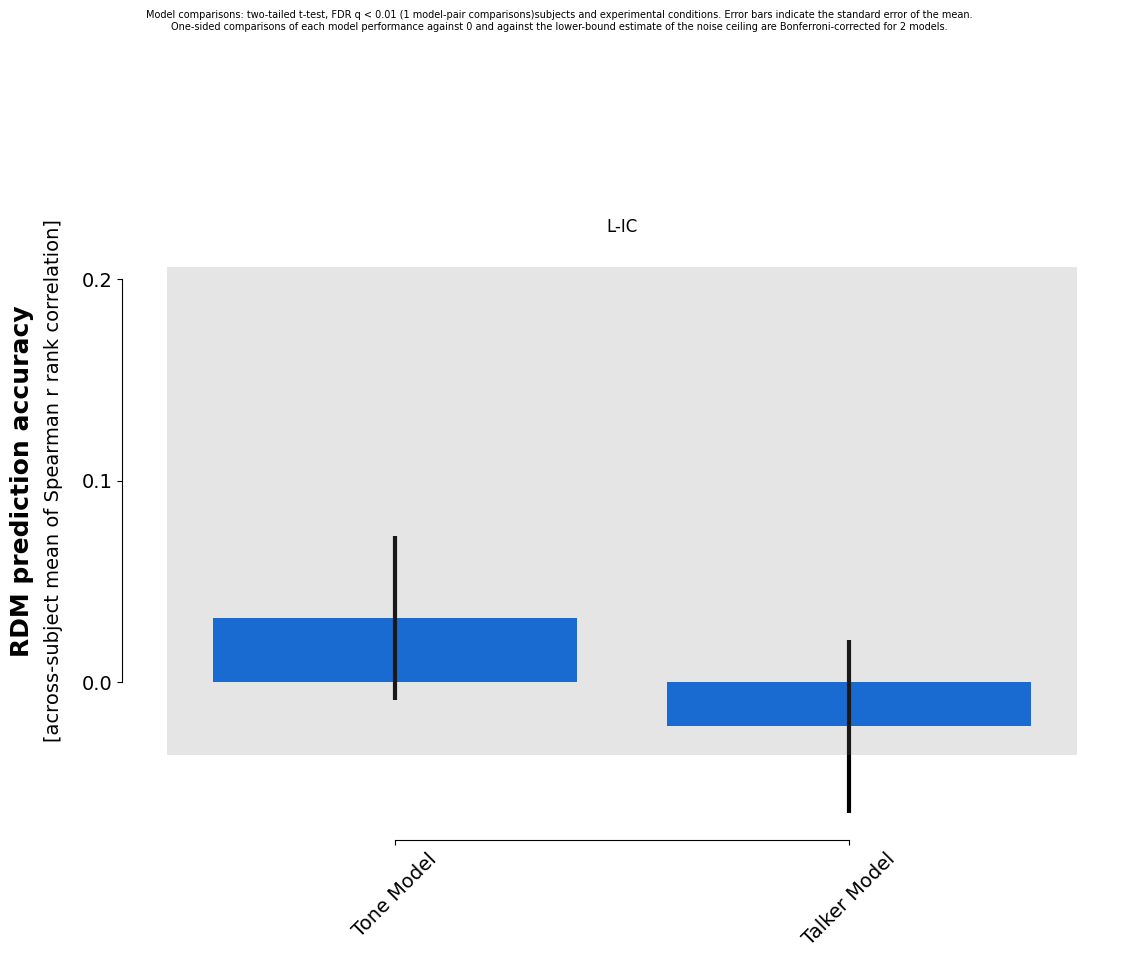

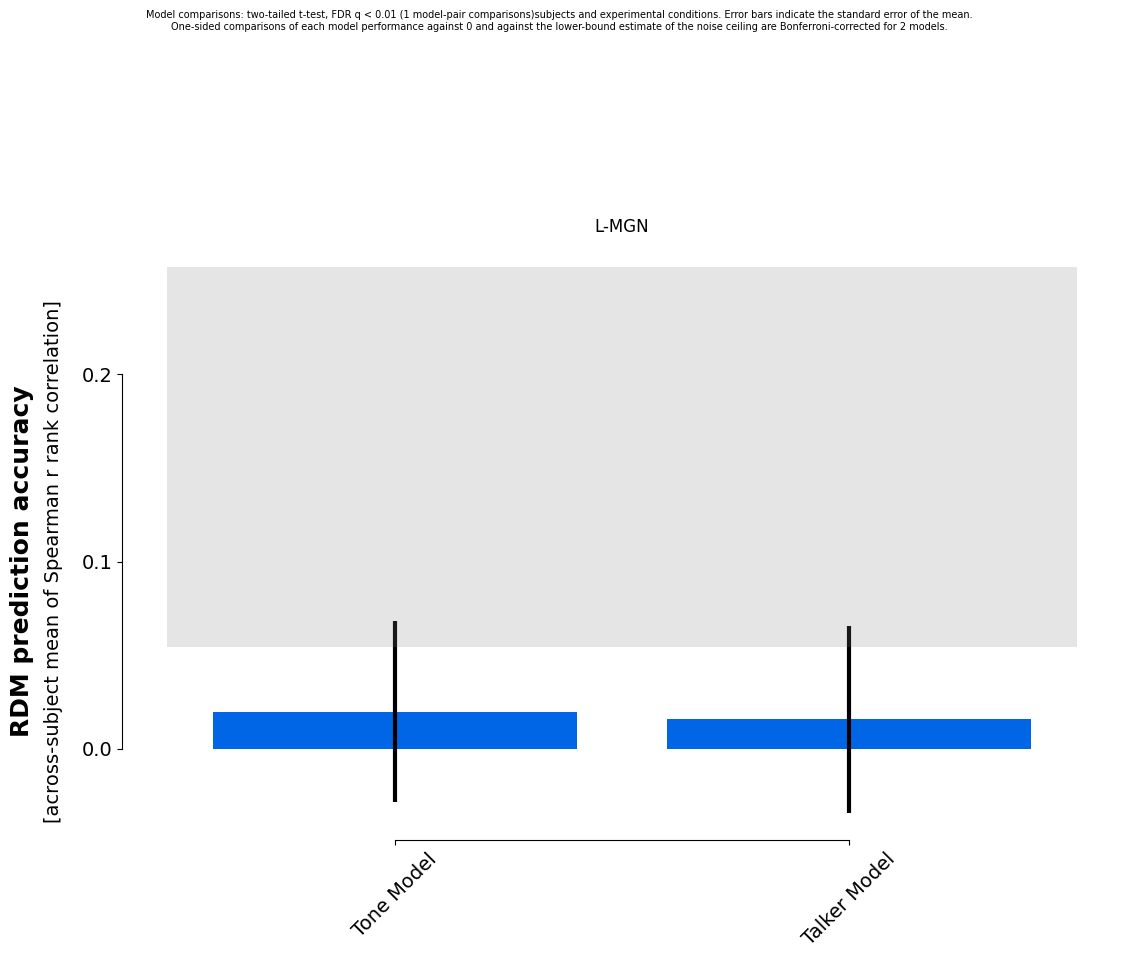

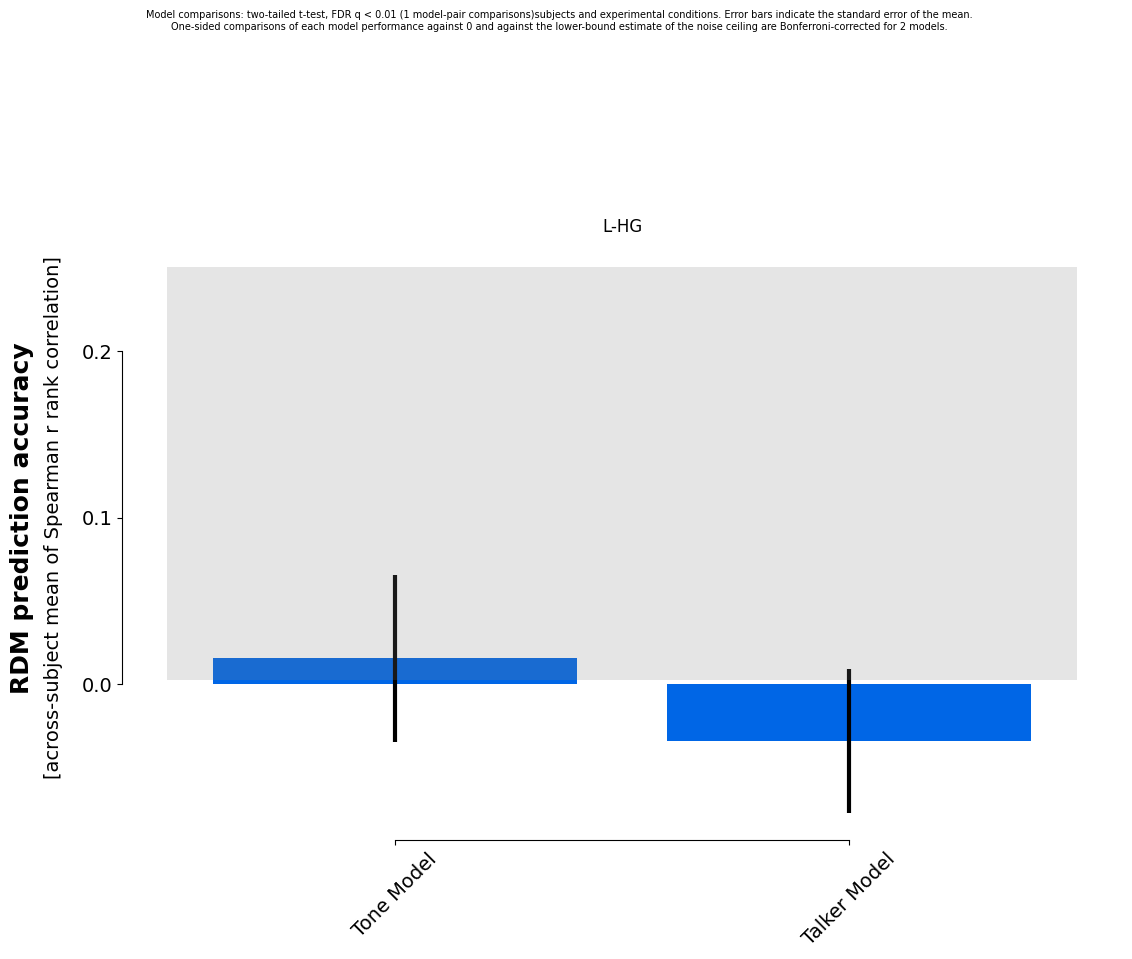

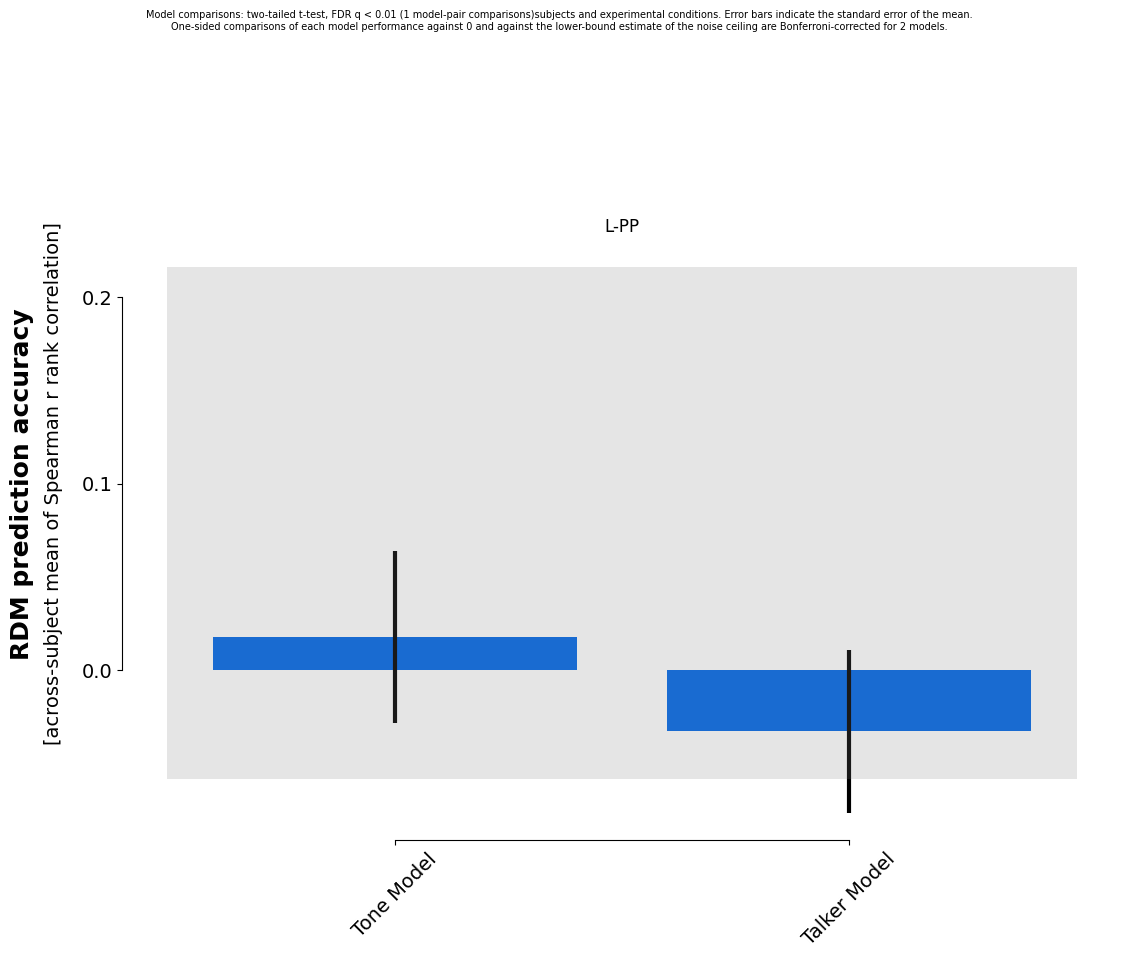

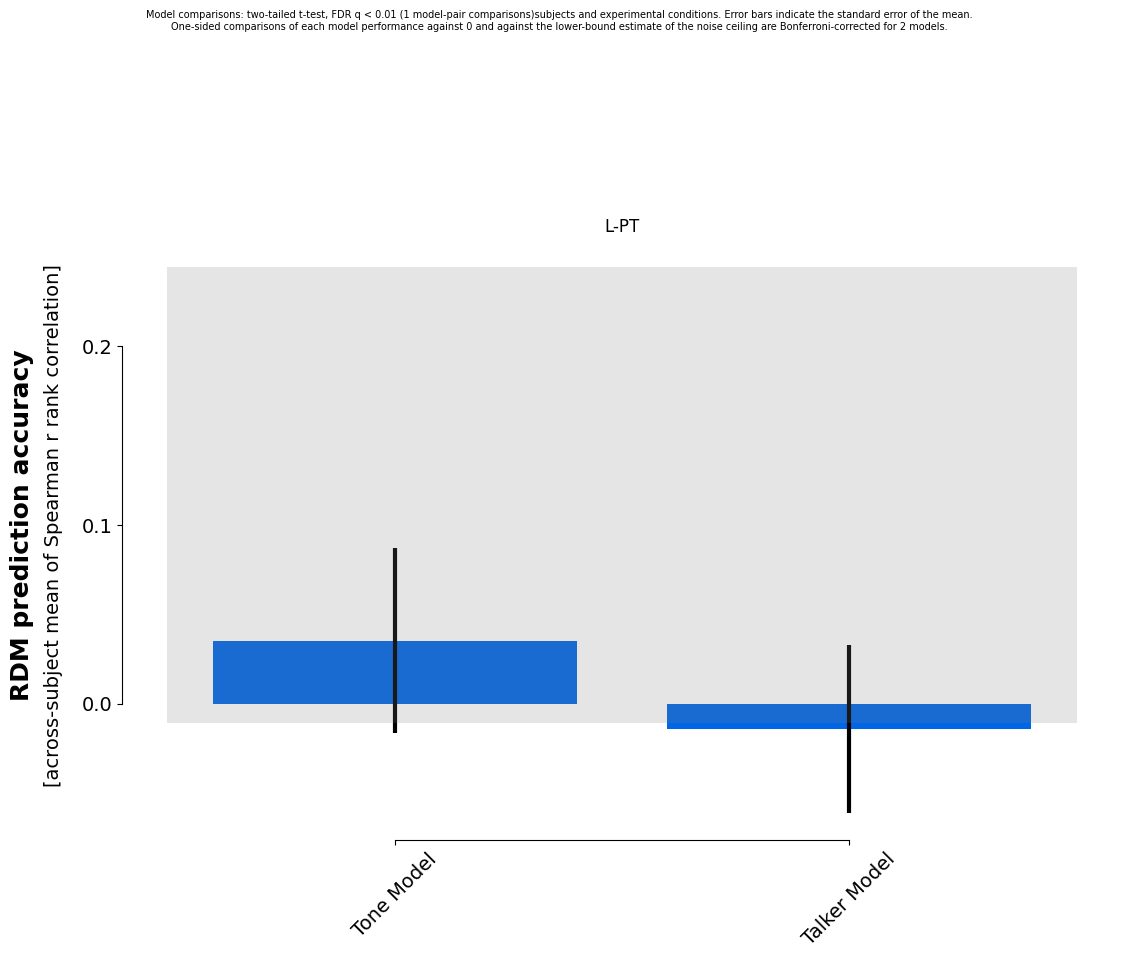

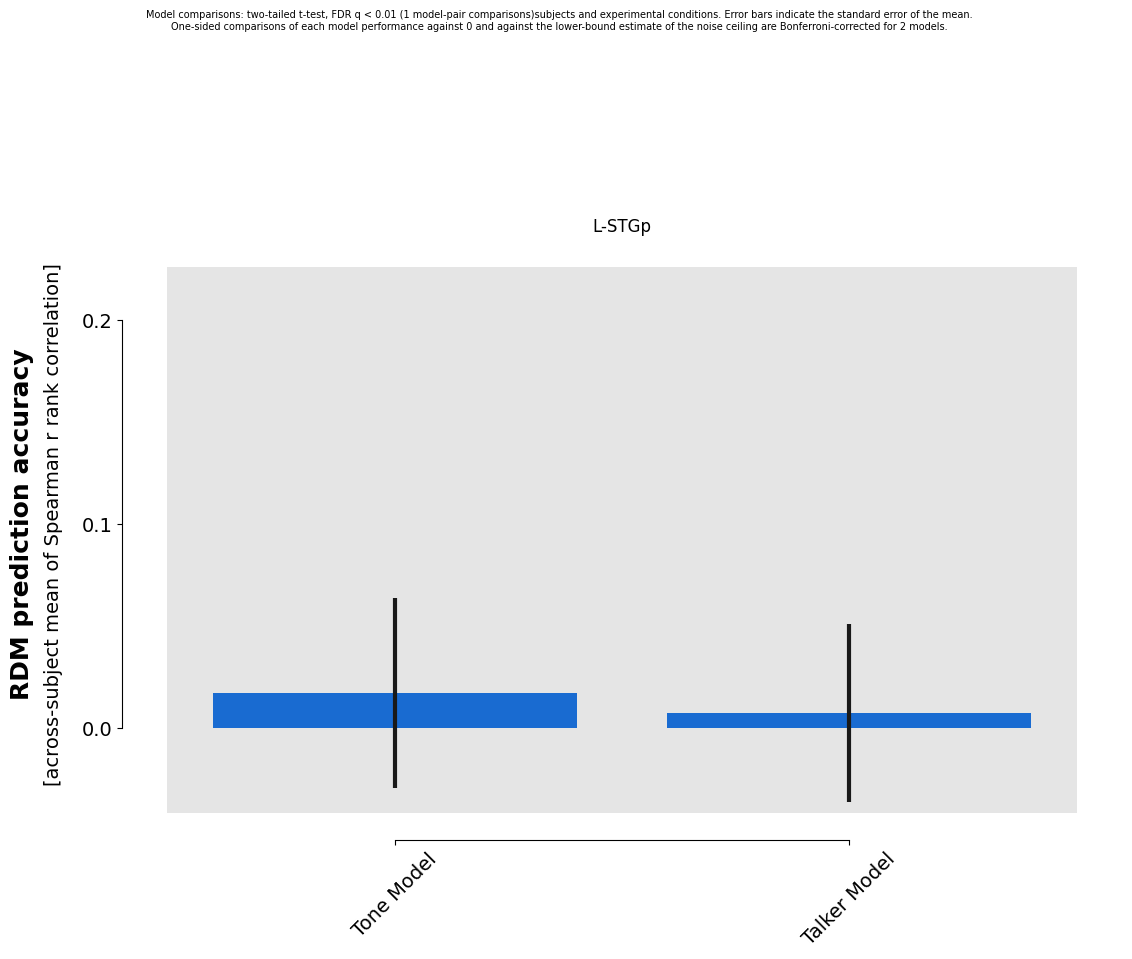

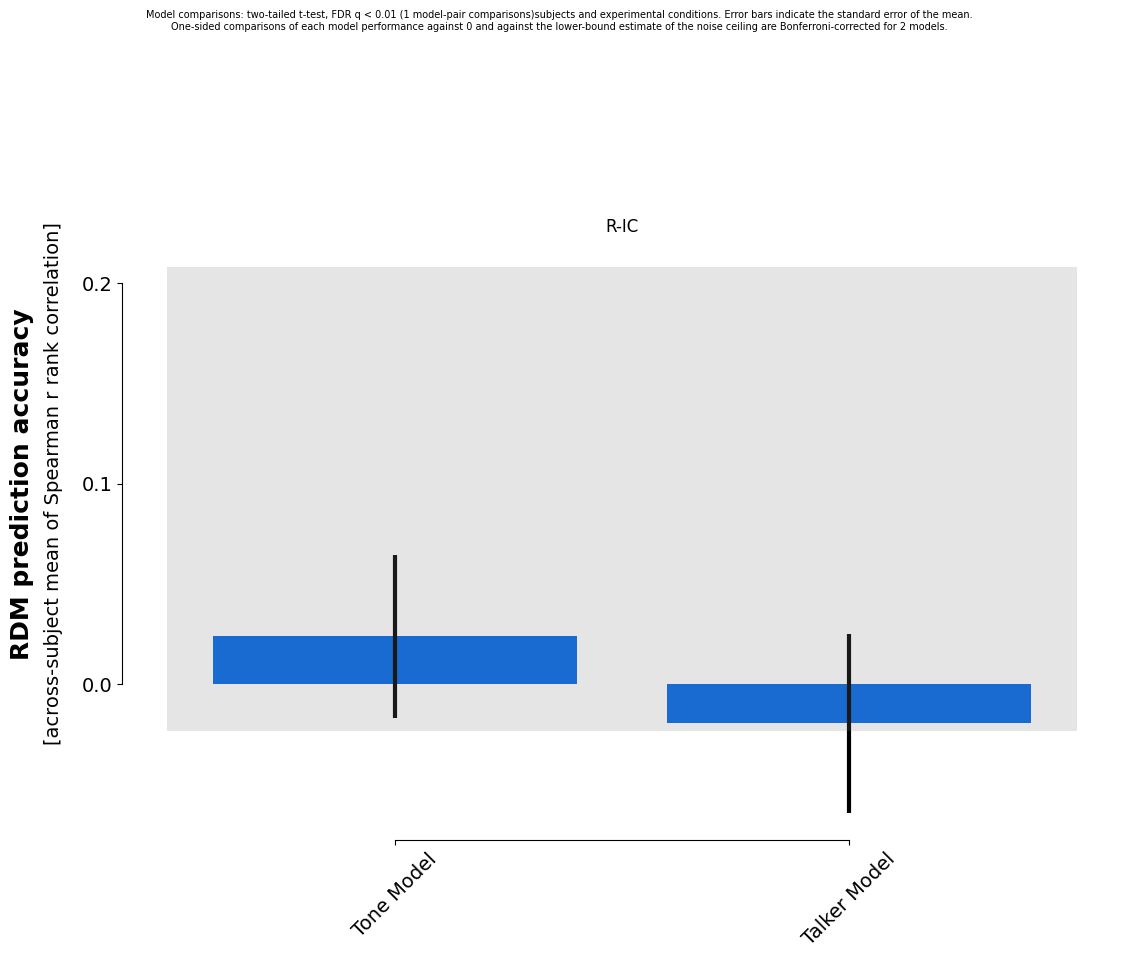

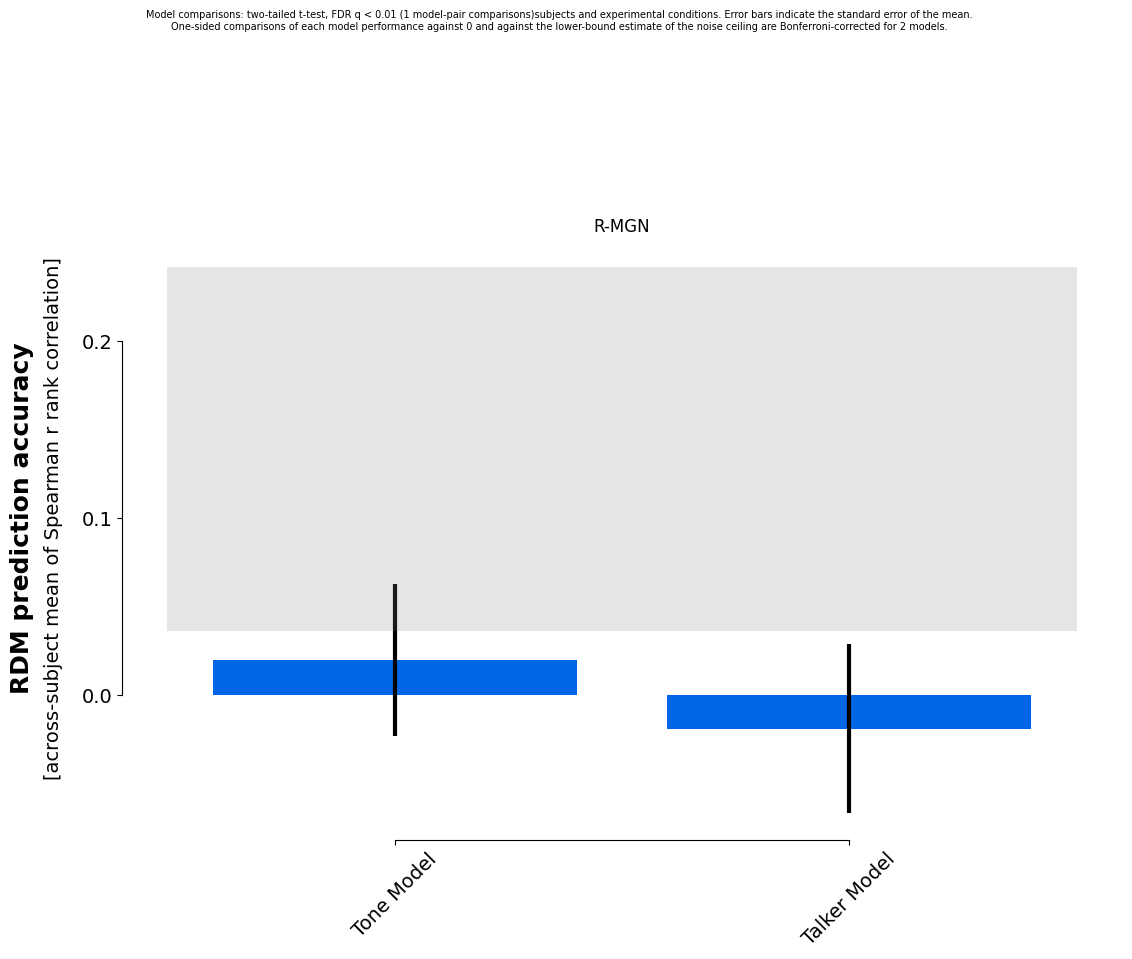

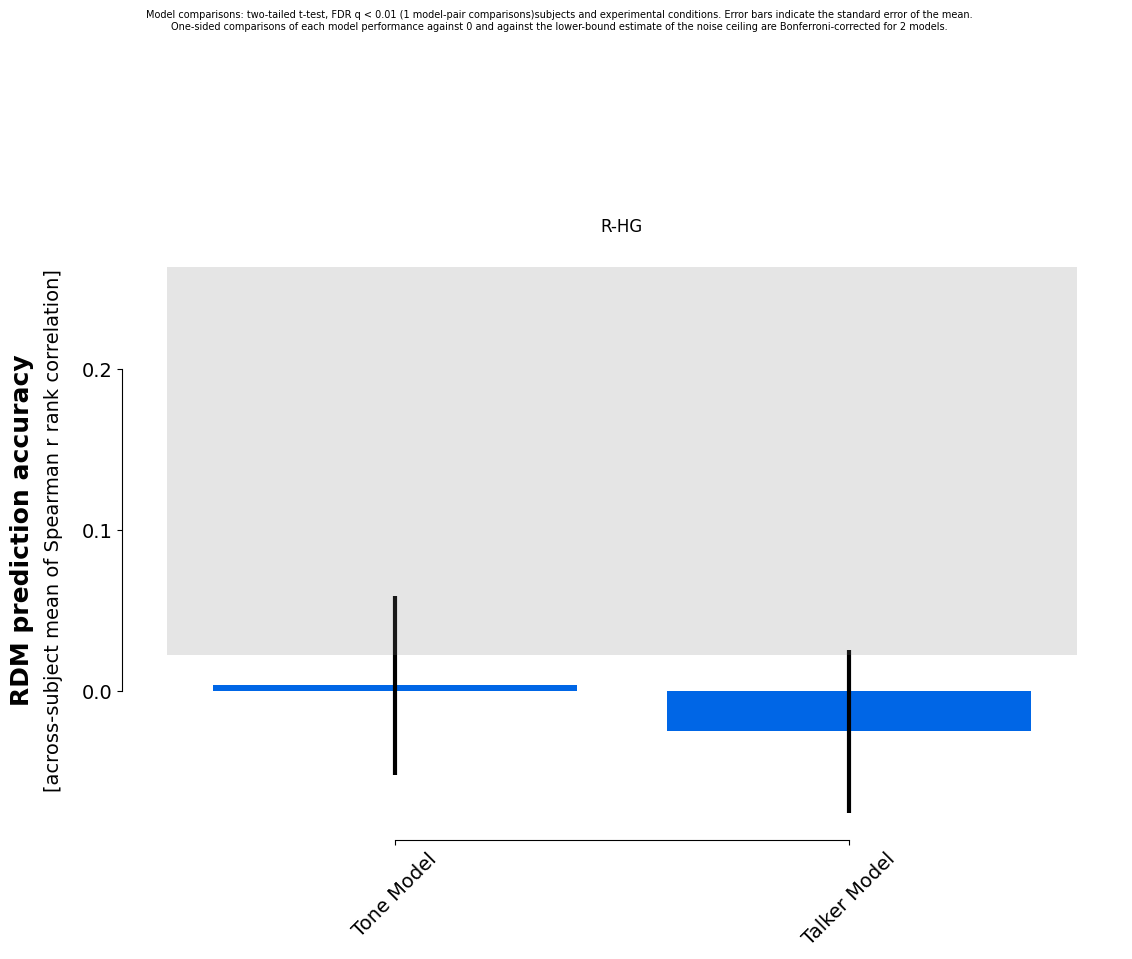

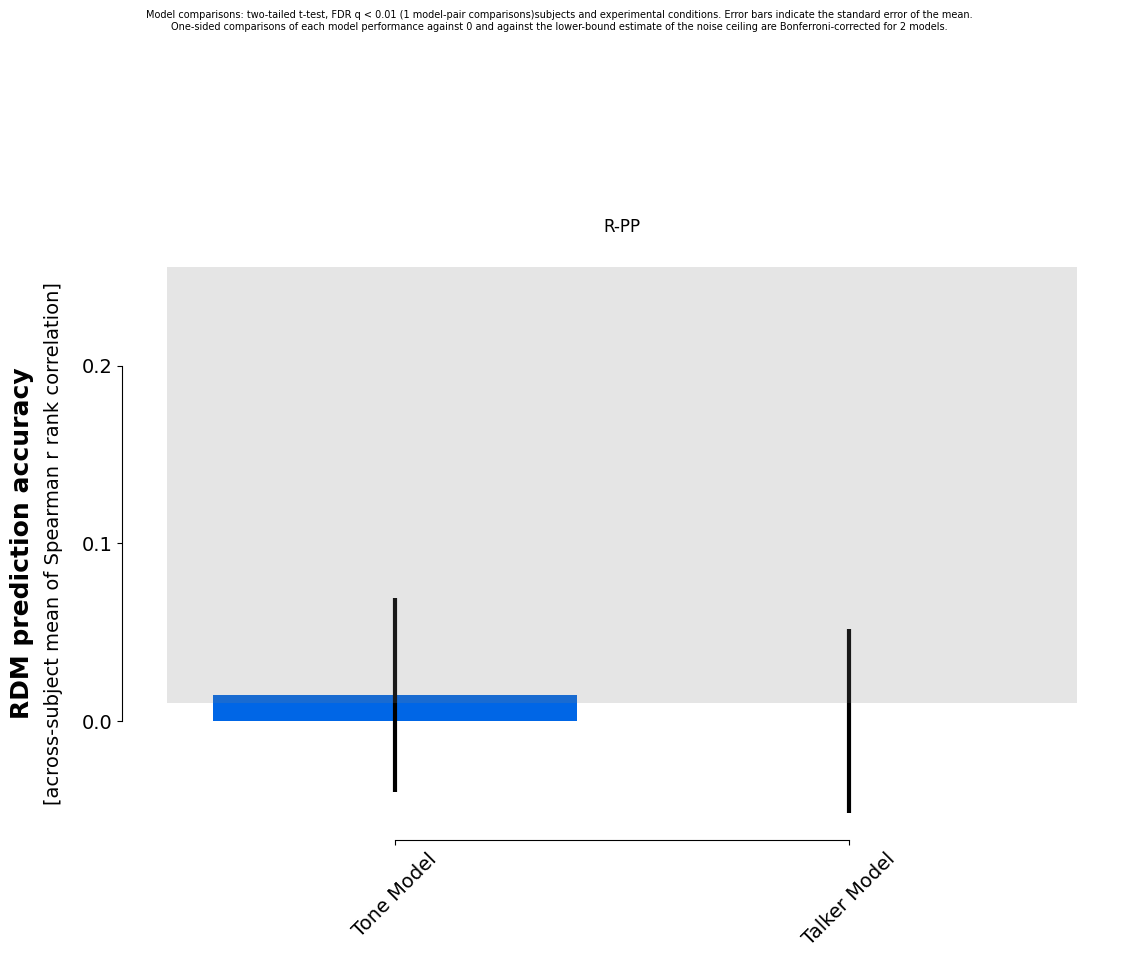

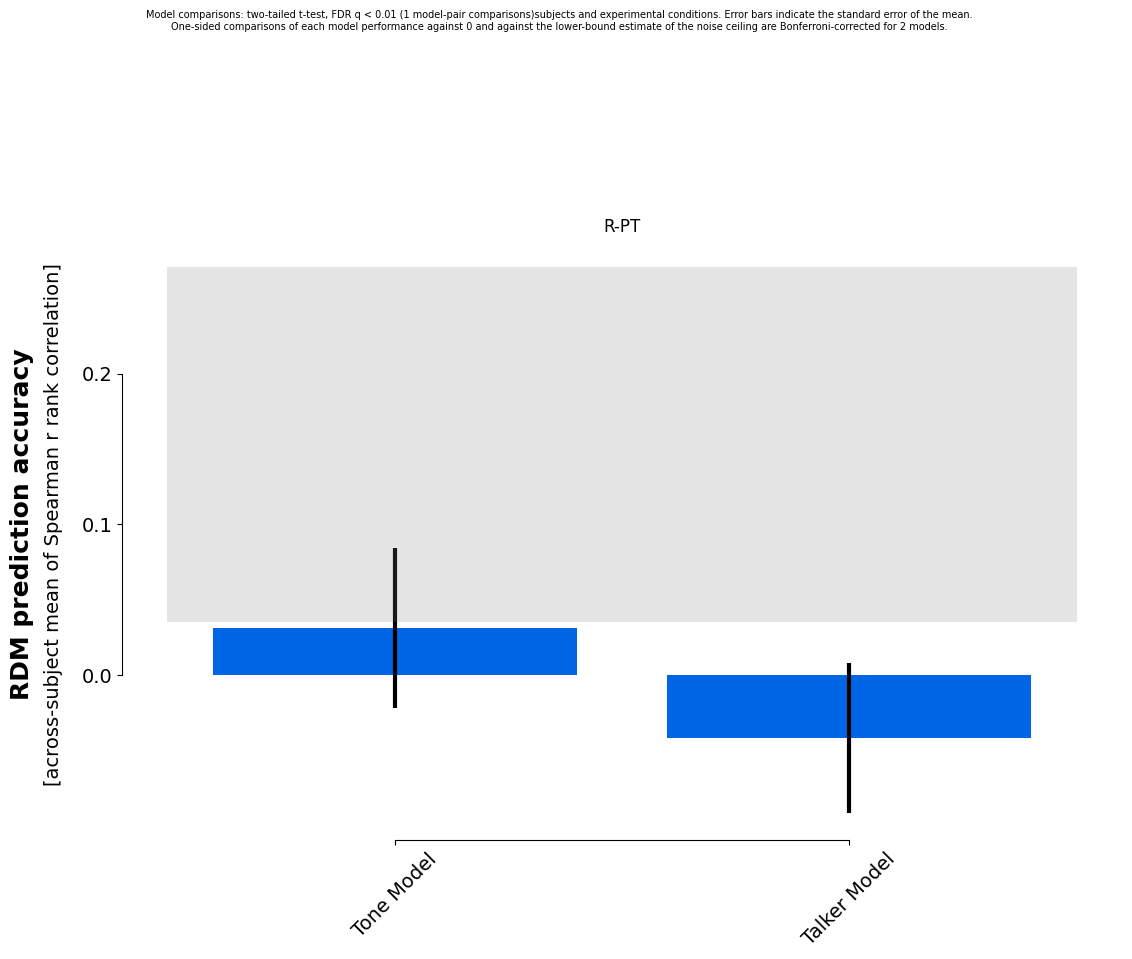

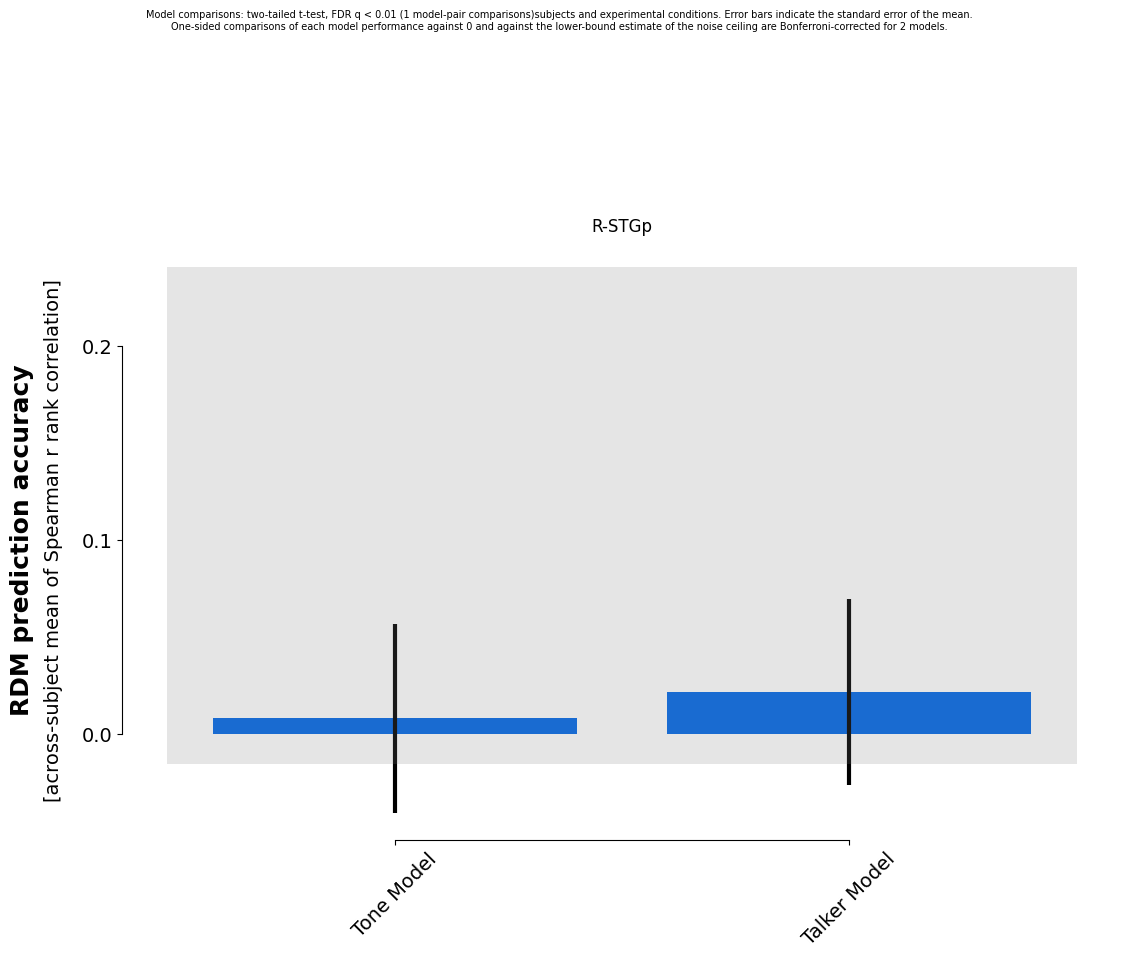

In [73]:
for rx, roi in enumerate(mask_list):
    print(roi)
    #results = rsatoolbox.inference.eval_fixed(cat_models, group_rdms.subset('ROI', value=roi))
    results = rsatoolbox.inference.eval_bootstrap(cat_models,
                                                  group_rdms.subset('ROI', value=roi),
                                                  method='spearman',
                                                  N=1000)
    fig, ax, _ = rsatoolbox.vis.plot_model_comparison(results)
    ax.set_title(roi)

### MDS

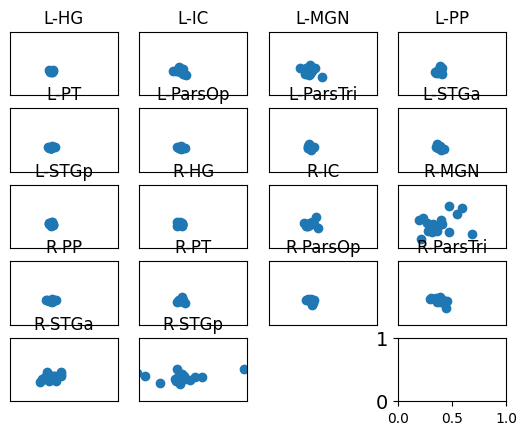

In [104]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_roi_rdms, 
                                     rdm_descriptor='ROI',
                                     #pattern_descriptor='stimulus',
                                    ).show()

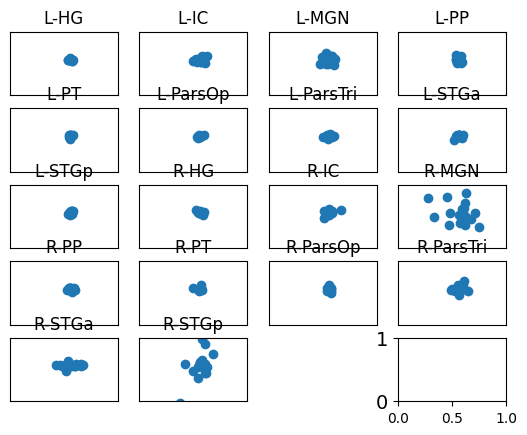

In [105]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_roi_rdms, 
                                     rdm_descriptor='ROI',
                                     #pattern_descriptor='stimulus',
                                    ).show()

## Run-specific

In [24]:
model_dir

'/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle'

### Load subject-specific RDMs

In [75]:
# from `rsa_roi.py`-generated outputs
calc_method = 'euclidean' # 'correlation'

group_rdm_list = []
for sx, sub_id in enumerate(participant_list):
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, f'rsa-roi_glmsingle_rdmcalc-{calc_method}')
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_glmsingle_trial_auditory_{calc_method}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # subject-level descriptors
    sub_rdm.descriptors['participant'] = sub_id
    sub_rdm.descriptors['group'] = group_id
    group_rdm_list.append(sub_rdm)
    
ref = group_rdm_list[0].pattern_descriptors['stimulus']
for rdm in group_rdm_list[1:]:
    assert rdm.pattern_descriptors['stimulus'] == ref

group_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list)

FLT02
FLT03
FLT04
FLT05
FLT09
FLT10
FLT11
FLT12
FLT13
FLT14
FLT15
FLT17
FLT18
FLT19
FLT20
FLT21
FLT22
FLT23
FLT24
FLT25
FLT26
FLT28
FLT30


In [76]:
group_rdms.n_cond

16

In [77]:
group_rdms.n_rdm

2148

In [78]:
group_rdms.pattern_descriptors.keys()


dict_keys(['index', 'run', 'stimulus'])

In [79]:
group_rdms.rdm_descriptors.keys()

dict_keys(['group', 'ROI', 'participant', 'run', 'index'])

In [80]:
square_dir = os.path.join(out_dir, 'rdm_csv')
os.makedirs(square_dir, exist_ok=True)

for rdm_i in range(group_rdms.n_rdm):

    rdm = group_rdms[rdm_i]

    sub = rdm.rdm_descriptors['participant'][0]
    roi = rdm.rdm_descriptors['ROI'][0]
    run = rdm.rdm_descriptors['run'][0]
    
    run_dir = os.path.join(square_dir, run)
    os.makedirs(run_dir, exist_ok=True)
    
    mat = squareform(rdm.dissimilarities[0])
    labels = rdm.pattern_descriptors['index']  # or 'condition'

    df = pd.DataFrame(mat, index=labels, columns=labels)

    fname = f'sub-{sub}_{run}_roi-{roi}_rdm.csv'
    df.to_csv(os.path.join(run_dir, fname))
    

In [81]:
print(square_dir)

/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/glmsingle/rsa-roi_glmsingle_rdmcalc-euclidean/rdm_csv


#### Group-average RDMs

In [82]:
roi_names = np.unique(group_rdms.rdm_descriptors['ROI'])

mean_roi_rdms = []

for roi in roi_names:
    roi_rdms = group_rdms.subset('ROI', roi)

    # ---- average across participants ----
    mean_rdm = roi_rdms.mean()

    # keep ROI info
    mean_rdm.rdm_descriptors['ROI'] = [roi]

    mean_roi_rdms.append(mean_rdm)

mean_roi_rdms = rsatoolbox.rdm.rdms.concat(mean_roi_rdms)


In [83]:
mean_roi_rdms

rsatoolbox.rdm.RDMs(
dissimilarity_measure = 
squared euclidean
dissimilarities = 
[[  8.79602546   8.365937     6.40447393 ...   9.057594     9.24693061
    8.8264196 ]
 [  8.35636765   8.23594215   7.024491   ...   8.11323638   7.80845176
    7.50567564]
 [ 10.72589733   9.78482053   9.53044084 ...  12.379313    11.8356021
   12.29378401]
 ...
 [ 17.0740222   18.74652328  15.36191434 ...  15.82749506  18.38188707
   17.11720985]
 [ 16.4787298   21.00378257  15.3547118  ...  19.85019161  20.3401108
   21.57099027]
 [736.25348803 674.65367498 585.41479626 ...  27.23188284  32.20289519
   29.49332155]]
descriptors = 
{}
rdm_descriptors = 
{'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], 'ROI': ['L-HG', 'L-IC', 'L-MGN', 'L-PP', 'L-PT', 'L-ParsOp', 'L-ParsTri', 'L-STGa', 'L-STGp', 'R-HG', 'R-IC', 'R-MGN', 'R-PP', 'R-PT', 'R-ParsOp', 'R-ParsTri', 'R-STGa', 'R-STGp']}
pattern_descriptors = 
{'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'run': ['r

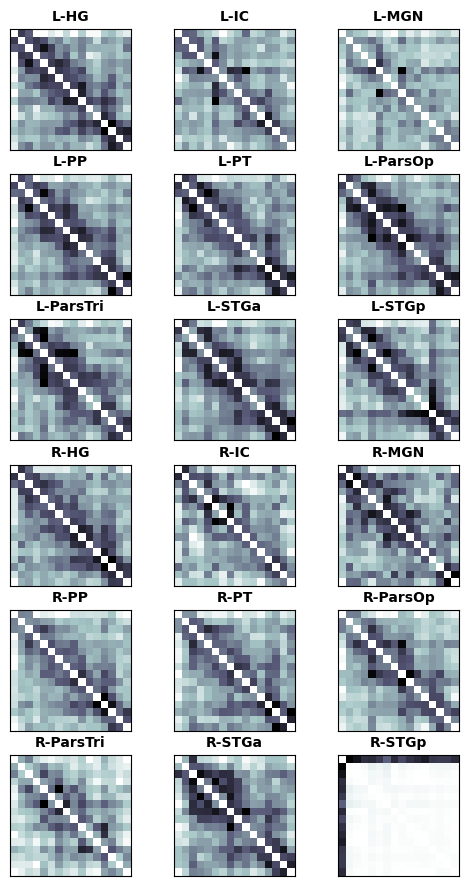

In [84]:
rsatoolbox.vis.show_rdm(mean_roi_rdms, 
                        rdm_descriptor='ROI', 
                        show_colorbar=None,#'panel', 
                        #pattern_descriptor='stimulus',
                        n_column=3,
                       )
plt.show()

In [ ]:
rdm_df = group_rdms.to_df()

In [ ]:
rdm_df

In [ ]:
results = rsatoolbox.inference.eval_fixed(cat_models, group_rdms, method='corr')
''''
results = rsatoolbox.inference.eval_bootstrap(
    cat_models,
    group_rdms,
    method='spearman',
    N=100
)
'''

In [ ]:
rsatoolbox.vis.plot_model_comparison(results)

#### Cross-validation

In [ ]:
train_set, test_set, ceil_set = rsatoolbox.inference.sets_k_fold(group_rdms)
results_cv = rsatoolbox.inference.crossval(cat_models, group_rdms, train_set, test_set, ceil_set=ceil_set, method='corr')

In [ ]:
rsatoolbox.vis.plot_model_comparison(results_cv)

In [ ]:
np.shape(train_set)

In [ ]:
np.shape(test_set)

In [ ]:
np.shape(ceil_set)

#### Separate RDM fits for each run

In [ ]:
from rsatoolbox.inference import eval_fixed

all_results = []

run_labels = np.array(group_rdms.rdm_descriptors['run'])
runs = sorted(set(run_labels))

for run in runs:
    run_idx = np.where(run_labels == run)[0]
    run_rdms = group_rdms[run_idx]

    run_results = eval_fixed(
        models=[tone_model, talker_model, rep_model],
        data=run_rdms,
        method='spearman'   # or 'regression'
    )

    all_results.append((run, run_results))


### plot data RDMs

In [ ]:
mask_list

In [ ]:
for rx, roi in enumerate(mask_list):
    print(roi)
    #results = rsatoolbox.inference.eval_fixed(cat_models, group_rdms.subset('ROI', value=roi))
    results = rsatoolbox.inference.eval_bootstrap(cat_models,
                                                  group_rdms.subset('ROI', value=roi),
                                                  method='spearman',
                                                  N=1000)
    fig, ax, _ = rsatoolbox.vis.plot_model_comparison(results)
    ax.set_title(roi)

### MDS

In [ ]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_roi_rdms, 
                                     rdm_descriptor='ROI',
                                     #pattern_descriptor='stimulus',
                                    ).show()

In [ ]:
rsatoolbox.vis.scatter_plot.show_MDS(mean_roi_rdms, 
                                     rdm_descriptor='ROI',
                                     #pattern_descriptor='stimulus',
                                    ).show()

### Model comparisons

In [ ]:
[x.name for x in all_models]

In [ ]:
'''
group = 'Mandarin'
ROI = 'mask-R-ParsTri'
'''
for group in np.unique(runall_rdms.rdm_descriptors['group']):
    for ROI in np.unique(runall_rdms.rdm_descriptors['ROI']):
        print(f'group-{group} ROI-{ROI}')
        results_grr = rsatoolbox.inference.eval_fixed(all_models, 
                                                      runall_rdms.subset('group', value=group).subset('ROI',value=ROI),  
                                                      method='corr',)
        fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr);
        ax1.set_title(f'group-{group} ROI-{ROI}');
        ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")
        #results_grr.save(f'results-eval/run-all/results-eval_run-all_group-{group}_ROI-{ROI}.hdf5',overwrite=True)
        

In [ ]:
print(results_mand.summary())

## TEST: Categorical model comparisons

In [ ]:
results_1 = []
for roi in mask_list:
    print(roi)
    results_1.append(rsatoolbox.inference.eval_fixed(cat_models, 
                                                     runall_rdms.subset('ROI', value=roi).subset('group', value='non-Mandarin'), 
                                                     method='corr',))


In [ ]:
for rx, roi in enumerate(mask_list):
    fig = rsatoolbox.vis.plot_model_comparison(results_1[rx])
    fig[0].suptitle(roi, fontsize=24)

## WIP: Hierarchical representation tests

In [ ]:
mean_rdms_mand

In [ ]:
neural_models_dict = {}

neural_models_dict['Mandarin'] = [ModelFixed(x, rdm=mean_rdms_mand.subset('group', value='Mandarin').subset('ROI',value=x)) for x in np.unique(mean_rdms_mand.rdm_descriptors['ROI'])]
neural_models_dict['non-Mandarin'] = [ModelFixed(x, rdm=mean_rdms_nman.subset('group', value='non-Mandarin').subset('ROI',value=x)) for x in np.unique(mean_rdms_nman.rdm_descriptors['ROI'])]


In [ ]:
for group in np.unique(runall_rdms.rdm_descriptors['group']): # ['non-Mandarin']:# 
    for ROI in np.unique(runall_rdms.rdm_descriptors['ROI']):
        #if 'PP' in ROI:
        #    continue
        print(f'group-{group} ROI-{ROI}')
        results_grr = rsatoolbox.inference.eval_fixed(neural_models_dict[group], 
                                                      runall_rdms.subset('group', value=group).subset('ROI',value=ROI),  
                                                      method='corr',)
        fig, ax1, ax2 = rsatoolbox.vis.plot_model_comparison(results_grr,
                                                             test_pair_comparisons='nili', #False, # getting a bug from plot_arrow()
                                                            );
        ax1.set_title(f'group-{group} ROI-{ROI}');
        ax1.axes.set_xticklabels(ax1.xaxis.get_majorticklabels(), ha="right")